In [84]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'Customer_ID': range(1, n+1),
    'Age': np.random.randint(25, 60, n),
    'Annual_Income': np.random.uniform(300000, 2000000, n),
    'Credit_Score': np.random.randint(500, 850, n),
    'Loan_Amount': np.random.randint(500000, 5000000, n),
    'Current_Interest_Rate': np.random.uniform(4.0, 7.0, n),
    'Years_With_Bank': np.random.randint(1, 15, n)
})

df['Market_Rate'] = 3.5 # กำหนดอัตราดอกเบี้ยตลาด
df.info()
print("*" * 150)

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            1000 non-null   int64  
 1   Age                    1000 non-null   int64  
 2   Annual_Income          1000 non-null   float64
 3   Credit_Score           1000 non-null   int64  
 4   Loan_Amount            1000 non-null   int64  
 5   Current_Interest_Rate  1000 non-null   float64
 6   Years_With_Bank        1000 non-null   int64  
 7   Market_Rate            1000 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 62.6 KB
******************************************************************************************************************************************************


,Customer_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Current_Interest_Rate,Years_With_Bank,Market_Rate
0,1,53,7.567515e+05,618,1858311,5.939801,10,3.5
1,2,39,1.220778e+06,570,1789467,4.680224,5,3.5
2,3,32,1.376913e+06,503,664074,6.010098,1,3.5
3,4,45,7.384091e+05,720,3070466,5.404991,2,3.5
4,5,43,5.369053e+05,513,4155180,6.320658,4,3.5


In [85]:
# สมมติ MRR ของธนาคารเราคือ 7.0% ลูกค้าแต่ละคนจะได้ส่วนลด (Discount) ไม่เท่ากันตามเกรด
df['Current_Interest_Rate'] = 7.0 - np.random.uniform(0.5, 3.0, n)
print(df.head())

   Customer_ID  Age  Annual_Income  Credit_Score  Loan_Amount  \
0            1   53   7.567515e+05           618      1858311   
1            2   39   1.220778e+06           570      1789467   
2            3   32   1.376913e+06           503       664074   
3            4   45   7.384091e+05           720      3070466   
4            5   43   5.369053e+05           513      4155180   

   Current_Interest_Rate  Years_With_Bank  Market_Rate  
0               5.041732               10          3.5  
1               4.289141                5          3.5  
2               6.120643                1          3.5  
3               5.005480                2          3.5  
4               4.838152                4          3.5  


In [86]:
# สร้าง Feature ส่วนต่างดอกเบี้ย
df['Rate_Spread'] = df['Current_Interest_Rate'] - df['Market_Rate']

In [87]:
# ส่วนต่างดอกเบี้ย + เครดิตสกอร์ (ยิ่งเครดิตดี ยิ่งกู้ที่ใหม่ง่าย)
df['Churn_Probability'] = (
    (df['Rate_Spread'] * 0.4) +           # Signal
    (df['Credit_Score'] / 850 * 0.2) +    # Second Signal
    np.random.normal(0, 0.1, n)                 # Add some Noise
)

# ให้คนที่มีค่าความเสี่ยงสูงสุด 15% แรก เป็นคนที่ย้ายออกจริงๆ (Exited = 1)
df['Exited'] = (df['Churn_Probability'] > df['Churn_Probability'].quantile(0.85)).astype(int)

In [88]:
# เลือกแค่ตัวแปรพื้นฐาน โดยบังคับไม่ให้มี Churn_Probability ใน features
features_to_use = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Current_Interest_Rate', 'Years_With_Bank', 'Rate_Spread']
X = df[features_to_use]
y = df['Exited']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [90]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [91]:
model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_res, y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [92]:
# Probability of Churn สำหรับการพล็อตกราฟ
y_probs = model.predict_proba(X_test)[:, 1]

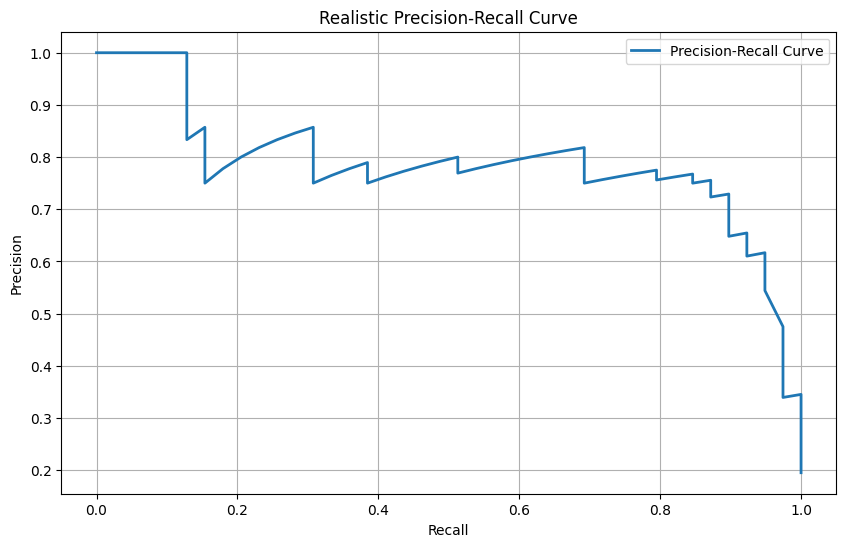

In [93]:
# Precision&Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label='Precision-Recall Curve', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Realistic Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.show()